# Milestone 3 Bonus 2: Explanation of Threat Index

- Why we chose these 4 variables?

Our threat index focus is on identifying the optimal spot for dangerous hail formation. For this, we used 4 variables for us to calculate our hail index. The variables we chose are Vertically Integrated Liquid (VIL) Density, Reflectivity, CAPE, and Vertical Velocity. We chose the 5-hour rolling time for all these variables to account for the impact of storms on the short range HRRR. As for specific variables, the positive correlation between VIL Density and hail is proven. As the diameter of detected targets increases, so does the VIL density. Frequently, hydrometeor targets with high diameters indicate hail. Therefore, the connection between VIL Density and hail is evident. Reflectivity has a similar relationship - increasingly large hydrometeor targets are generally hail rather than raindrops. This "changeover" is generally around 50-70 dBZ, which is indicated in the formula for the reflectivity portion of the index. CAPE is short for Convective Available Potential Energy. Essentially, it describes a parcel's ability to rise freely based on atmospheric conditions and energy. The more CAPE is present, the more of a mechanism a parcel has to rise and eventually form a storm that would likely be conducive to producing hail. Lastly, vertical velocity is connected to hail in terms of the speed of the rising parcel - the faster the rising parcel, the more it can punch through any atmospheric CAP and form storms that are conducive to hail.

In [3]:
#Code for calling the file and creating a base map to plot the hail index on
from herbie import Herbie, FastHerbie
from herbie.toolbox import EasyMap, pc
from herbie import paint
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta, time, timezone
import pandas as pd, numpy as np
import xarray as xr
import dask

ds_file = xr.open_dataset("hrrr_2026031012.nc") #ds_file used to open the netcdf file in order for us to use the data to create plots
ds_file
ds_file = ds_file.rename({"unknown":"cloudtop"})

def map(): #map function used to create our base maps when needed
    fig = plt.figure(figsize=(12,9)) #figure size for us to place our base map
    ax = fig.add_subplot(111, projection=ccrs.LambertConformal()) #projection used for our base map
    ax.set_extent([-107,-79,26,44], ccrs.PlateCarree()) #set extent for our base map to zoom into our area of interest
    ax.add_feature(cfeature.COASTLINE) #coastlines added on our map 
    ax.add_feature(cfeature.STATES, linestyle=':')
    ax.add_feature(cfeature.BORDERS)
    return fig, ax

lon = ds_file['longitude'] #getting the longitude from our ds_file so we can plot our data
lat = ds_file['latitude'] #gettting the latitude from our ds_file so we can plot our data
dataproj = ccrs.PlateCarree() #making PlateCarree in our dataproj so we can add it to our pcolormesh

sh: 1: getfattr: not found


In [4]:
#Code for creating individual index
# Start with all contributions set to 0
#Code for the VIL density index
vil_density =  (ds_file["veril"] /  ds_file["cloudtop"]) *100
vil_density_5hr_rolling = vil_density.rolling(valid_time=5).max()
def vil_density_index(ds_file,step): #created a function to make it easier to plot the index at different steps
# Start with all contributions set to 0
    vil_density_5hr_rolling_time =vil_density_5hr_rolling.isel(valid_time=step).values
    vil_density_contribution = np.zeros_like(vil_density_5hr_rolling_time)

    mask = (vil_density_5hr_rolling_time >= 0.25) & (vil_density_5hr_rolling_time < 1.75 )
    vil_density_contribution[mask] = (vil_density_5hr_rolling_time[mask] - 0.25) / 1.50

    mask = (vil_density_5hr_rolling_time >= 1.75) 
    vil_density_contribution[mask] = 1.0
    return vil_density_contribution

#Code for the reflectivity index
def refc_index(ds_file, step): #created a function to make it easier to plot the index at different steps
    refc_5hr_rolling = ds_file['refc'].rolling(valid_time=5).max()
    refc_5hr_rolling_time = refc_5hr_rolling.isel(valid_time=step).values
    refc_contribution = np.zeros_like(refc_5hr_rolling_time)

    # Setting the index = 0 if reflectivity is less than 45 
    mask = refc_5hr_rolling_time < 45
    refc_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for reflectivity in betwene 45 and 60 (inclusive)
    mask = (refc_5hr_rolling_time >= 45) & (refc_5hr_rolling_time <= 60)
    refc_contribution[mask] = ((refc_5hr_rolling_time[mask] - 45) / 15)

    # Setting the index = 1 if reflectivty is greater than 60
    mask = refc_5hr_rolling_time > 60
    refc_contribution[mask] = 1
    return refc_contribution

#Code for the CAPE index
def cape_index(ds_file,step): #created a function to make it easier to plot the index at different steps

    cape_5hr_rolling = ds_file['cape'].rolling(valid_time=5).max()
    cape_5hr_rolling_time = cape_5hr_rolling.isel(valid_time=step).values
    cape_contribution = np.zeros_like(cape_5hr_rolling_time)

    # Setting the index = 0 if CAPE is less than 1250
    mask = (cape_5hr_rolling_time < 1250)
    cape_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for CAPE in between 1250 and 2500 (inclusive)
    mask = (cape_5hr_rolling_time >= 1250) & (cape_5hr_rolling_time <= 2500)
    cape_contribution[mask] = (cape_5hr_rolling_time[mask] - 1250) / 1250

    # Setting the index = 1 if CAPE is greater than 2500
    mask = cape_5hr_rolling_time > 2500
    cape_contribution[mask] = 1
    return cape_contribution

#Code for the vertical velocity index
def vert_velo_index(ds_file,step): #created a function to make it easier to plot the index at different steps
#Vertical Velocity Parameter Index
    vert_velo_5hr_rolling = ds_file["wz"].rolling(valid_time=5).max()
    vert_velo_5hr_rolling_time = vert_velo_5hr_rolling.isel(valid_time=step).values
    vert_velo_contribution = np.zeros_like(vert_velo_5hr_rolling_time)

    mask = (vert_velo_5hr_rolling_time >= 0) & (vert_velo_5hr_rolling_time < 0.55)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0) / 1.45

    mask = (vert_velo_5hr_rolling_time >= 0.55) & (vert_velo_5hr_rolling_time < 1.2)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0.20) / 1

    mask = (vert_velo_5hr_rolling_time >= 1.2)
    vert_velo_contribution[mask] = 1
    return vert_velo_contribution

# Explanation of Code Above

The code above shows how the index for each individual variable was calculated. It took a lot of trial and error for us to be happy with the best combinations and to really see which variable had the most effect on hail formation. For each variable, we created a function to make it easier to call when we needed to plot it at certain time steps to compare which variable was the best for hail formation. 

Individual Variable Weightings:
CAPE is indexed using a combination of constant ranges combined with a linearly increasing range in order to create an index that connects medium to large CAPE values with high chances of hail. The linear increase occurs between 1250 and 2500 J of CAPE, where CAPE becomes high enough to support hailstorms. 
Reflectivity is also indexed using a combination of constant ranges and a linearly increasing range. This is because at low values of reflectivity, hail is pretty much impossible. At high values of reflectivity, hail is very likely. At medium values of reflectivity, there is a sharp increase around 50-60 dBZ where hail becomes significantly more likely, hence where the linear increase is implemented. 
VIL Density is indexed using a small constant range, a large range of linear increase, and then another constant range. The VIL Density is indexed like this because there is a correlation between hydrometeor diameter and hail probability, and hydrometeor diameter is a significant factor in the VIL Density equation. Generally, VIL Density becomes viable for hail between 0.25 and 0.75 kg/m^2.
Vertical velocity is indexed using two linearly increasing fits and a constant range. It's indexed like this because vertical velocity has a positive correlation with hail probability up to a little over 1 m/s, when the hail probability stops increasing.

In [5]:
#Code for the hail index equation

#Code for implementing the algorithm function worked on by Myles, Jonathan, and Manuel
# Research used to inform our weighting: 
# https://www.weather.gov/ohx/vildensityhailsize
# https://www.weather.gov/media/wrh/online_publications/TAs/TA1005.pdf
def hail_index(ds_file,step):
    cape_5hr_rolling = ds_file['cape'].rolling(valid_time=5).max()
    cape_5hr_rolling_time = cape_5hr_rolling.isel(valid_time=step).values
    cape_contribution = np.zeros_like(cape_5hr_rolling_time)

    # Setting the index = 0 if CAPE is less than 1250
    mask = (cape_5hr_rolling_time < 1250)
    cape_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for CAPE in between 1250 and 2500 (inclusive)
    mask = (cape_5hr_rolling_time >= 1250) & (cape_5hr_rolling_time <= 2500)
    cape_contribution[mask] = (cape_5hr_rolling_time[mask] - 1250) / 1250

    # Setting the index = 1 if CAPE is greater than 2500
    mask = cape_5hr_rolling_time > 2500
    cape_contribution[mask] = 1

    refc_5hr_rolling = ds_file['refc'].rolling(valid_time=5).max()
    refc_5hr_rolling_time = refc_5hr_rolling.isel(valid_time=step).values
    refc_contribution = np.zeros_like(refc_5hr_rolling_time)

    # Setting the index = 0 if reflectivity is less than 45 
    mask = refc_5hr_rolling_time < 45
    refc_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for reflectivity in betwene 45 and 60 (inclusive)
    mask = (refc_5hr_rolling_time >= 45) & (refc_5hr_rolling_time <= 60)
    refc_contribution[mask] = ((refc_5hr_rolling_time[mask] - 45) / 15)

    # Setting the index = 1 if reflectivty is greater than 60
    mask = refc_5hr_rolling_time > 60
    refc_contribution[mask] = 1

    vil_density_5hr_rolling_time =vil_density_5hr_rolling.isel(valid_time=step).values
    vil_density_contribution = np.zeros_like(vil_density_5hr_rolling_time)

    mask = (vil_density_5hr_rolling_time >= 0.25) & (vil_density_5hr_rolling_time < 1.75 )
    vil_density_contribution[mask] = (vil_density_5hr_rolling_time[mask] - 0.25) / 1.50

    mask = (vil_density_5hr_rolling_time >= 1.75) 
    vil_density_contribution[mask] = 1.0

    #vert velo index being created
    vert_velo_5hr_rolling = ds_file["wz"].rolling(valid_time=5).max()
    vert_velo_5hr_rolling_time = vert_velo_5hr_rolling.isel(valid_time=step).values
    vert_velo_contribution = np.zeros_like(vert_velo_5hr_rolling_time)

    mask = (vert_velo_5hr_rolling_time >= 0) & (vert_velo_5hr_rolling_time < 0.55)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0) / 1.45

    mask = (vert_velo_5hr_rolling_time >= 0.55) & (vert_velo_5hr_rolling_time < 1.2)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0.20) / 1

    mask = (vert_velo_5hr_rolling_time >= 1.2)
    vert_velo_contribution[mask] = 1

    hail_index_calc = (cape_contribution * 0.20 + refc_contribution * 0.225 + vil_density_contribution * 0.35 + vert_velo_contribution * 0.225) * 100
    return hail_index_calc

# Explanation of Hail Index Equation Code

The code above shows how the hail index was calculated. Our approach to calculating the hail index was to add the indexes for the 4 variables that we coded inside the hail index function. At the bottom of the hail index function, we also added hail_index_calc. The hail_index_calc is the equation we use to calculate the hail index for each time step to identify where hail formation is most likely. The decimal points, such as 0.2 * cape_contribution or 0.225 * refc_contribution, indicate how much each variable is weighted.  

Equation weightings:
VIL Density is weighted the highest (*.35) because it has been proven to have a particularly significant correlation with hail probability (demonstrated in research cited above). It also is exceptionally good at highlighting very pinpointed areas of significant hail, with areas of high VIL Density lining up with storm reports from the event. Reflectivity and vertical velocity are weighted at 0.225. Reflectivity provides a significant correlation based on size of hydrometeors, but there can still be discrepancies due to very large raindrops or other flying items. Similarly, high vertical veloctiy is a good start if you want to see hail, but VIL Density seems to be an even stronger indicator. CAPE is weighted the least at 0.20. While definitely an important factor, high CAPE values span such a large area that it can only be so good of an indicator for hail reports and storms that can be hyperlocalized. 


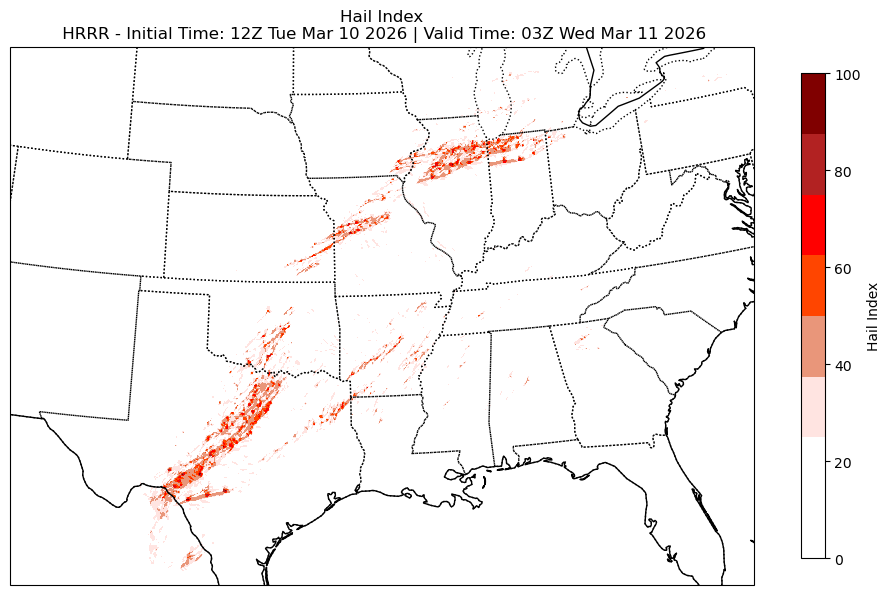

In [8]:
#Code for plotting hail index at time step 15Z
custom_cmap = [ #from notebook.community
    "white", # ND
    "white", # -30
    "mistyrose", # -25
    "darksalmon", # -20
    "orangered", # -15
    "red", # -10
    "firebrick", # -5
    "maroon", # 0
    ]

realcmap = ListedColormap(custom_cmap, name='nws_reflectivity_colors')

fig, ax = map() #calling map function
pcolor = ax.pcolormesh(lon, lat, hail_index(ds_file,15), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 15
plt.colorbar(pcolor, ax=ax, label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
ax.set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d %Y}") #title for map at step 15 with model name, valid time and initial time
plt.show()

![SPC Reports on March 10 2026](https://www.spc.noaa.gov/climo/reports/260310_rpts.gif)

The plot above shows the locations with the highest likelihood of dangerous hail formation. We also changed the colormap to make the areas with the best chances of dangerous hail formation stand out and be more noticeable to people. On the right is a colorbar that shows the areas with the highest likelihood of dangerous hail formation. Using the SPC storm reports, you can compare the reports given on that day with our hail index. As you can see when comparing both, some of the darkest colors on our hail index are in areas with many hail reports, specifiically large hail reports (2" diameter+).